# KV Cache Memory Math From Scratch

Goal: build intuition with exact tensor shapes, byte counts, and plots.

No `attention_forge` imports here. The notebook derives the ideas first; package
code is the tested reusable version.

##  Setup

We use only standard Python, NumPy, and Matplotlib.

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

DTYPE_BYTES = {
    "fp32": 4,
    "bf16": 2,
    "fp16": 2,
    "fp8": 1,
}

CONFIG = {
    "batch_size": 1,
    "num_layers": 32,
    "num_query_heads": 32,
    "head_dim": 128,
    "dtype": "fp16",
}


def bytes_to_gib(num_bytes):
    return num_bytes / 1024**3


def bytes_to_mib(num_bytes):
    return num_bytes / 1024**2


def fmt_bytes(num_bytes):
    if num_bytes >= 1024**3:
        return f"{bytes_to_gib(num_bytes):.3f} GiB"
    if num_bytes >= 1024**2:
        return f"{bytes_to_mib(num_bytes):.3f} MiB"
    if num_bytes >= 1024:
        return f"{num_bytes / 1024:.3f} KiB"
    return f"{num_bytes} B"


def print_table(headers, rows):
    widths = [len(str(header)) for header in headers]
    for row in rows:
        for idx, value in enumerate(row):
            widths[idx] = max(widths[idx], len(str(value)))
    template = "  ".join(f"{{:<{width}}}" for width in widths)
    print(template.format(*headers))
    print(template.format(*["-" * width for width in widths]))
    for row in rows:
        print(template.format(*[str(value) for value in row]))

## Q/K/V Shapes

For one transformer layer:

```text
x: [batch, sequence_length, hidden_size]
q: [batch, num_query_heads, sequence_length, head_dim]
k: [batch, num_kv_heads,    sequence_length, head_dim]
v: [batch, num_kv_heads,    sequence_length, head_dim]
```

`num_kv_heads` is the key variable for cache size.

In [30]:
def qkv_shapes(seq_len, num_kv_heads):
    batch = CONFIG["batch_size"]
    q_heads = CONFIG["num_query_heads"]
    head_dim = CONFIG["head_dim"]
    hidden_size = q_heads * head_dim
    return {
        "x": [batch, seq_len, hidden_size],
        "q": [batch, q_heads, seq_len, head_dim],
        "k": [batch, num_kv_heads, seq_len, head_dim],
        "v": [batch, num_kv_heads, seq_len, head_dim],
    }


rows = []
for name, shape in qkv_shapes(seq_len=2048, num_kv_heads=32).items():
    rows.append([name, shape])

print_table(["tensor", "shape"], rows)

tensor  shape             
------  ------------------
x       [1, 2048, 4096]   
q       [1, 32, 2048, 128]
k       [1, 32, 2048, 128]
v       [1, 32, 2048, 128]


## Prefill vs Decode

Prefill computes all prompt Q/K/V. Decode computes one new query and reads old
K/V from cache.

In [31]:
def decode_shapes(cache_len, num_kv_heads):
    batch = CONFIG["batch_size"]
    q_heads = CONFIG["num_query_heads"]
    head_dim = CONFIG["head_dim"]
    return [
        ["current_q", [batch, q_heads, 1, head_dim]],
        ["cached_k", [batch, num_kv_heads, cache_len, head_dim]],
        ["cached_v", [batch, num_kv_heads, cache_len, head_dim]],
        ["scores", [batch, q_heads, 1, cache_len]],
    ]


print_table(["tensor", "decode shape"], decode_shapes(2048, 32))

tensor     decode shape      
---------  ------------------
current_q  [1, 32, 1, 128]   
cached_k   [1, 32, 2048, 128]
cached_v   [1, 32, 2048, 128]
scores     [1, 32, 1, 2048]  


## Exact KV-Cache Memory

Head-based cache:

```text
bytes = batch * seq_len * layers * kv_heads * head_dim * 2 * dtype_bytes
```

The `2` is K plus V.

In [32]:
def kv_cache_bytes(
    seq_len,
    num_kv_heads,
    batch_size=CONFIG["batch_size"],
    num_layers=CONFIG["num_layers"],
    head_dim=CONFIG["head_dim"],
    dtype=CONFIG["dtype"],
):
    return (
        batch_size
        * seq_len
        * num_layers
        * num_kv_heads
        * head_dim
        * 2
        * DTYPE_BYTES[dtype]
    )


rows = []
for seq_len in [4096, 8192, 32768, 131072, 1_000_000]:
    memory = kv_cache_bytes(seq_len, num_kv_heads=32)
    rows.append([seq_len, fmt_bytes(memory), f"{bytes_to_gib(memory):.3f}"])

print_table(["seq_len", "MHA KV cache", "GiB"], rows)

seq_len  MHA KV cache  GiB    
-------  ------------  -------
4096     2.000 GiB     2.000  
8192     4.000 GiB     4.000  
32768    16.000 GiB    16.000 
131072   64.000 GiB    64.000 
1000000  488.281 GiB   488.281


## 4. KV Cache Growth Plot

Same formula, plotted for MHA/MQA/GQA and a simplified MLA cache model.

Important: `MLA latent 512` means 512 cached latent scalars per token per layer.
It is not 512 heads. In this notebook, MLA is a simplified accounting model:

```text
MLA cache bytes = batch * seq_len * layers * latent_dim * dtype_bytes
```

Real MLA implementations may store extra positional dimensions or use a more
specific projection layout, but the core memory lever is the latent cache width.

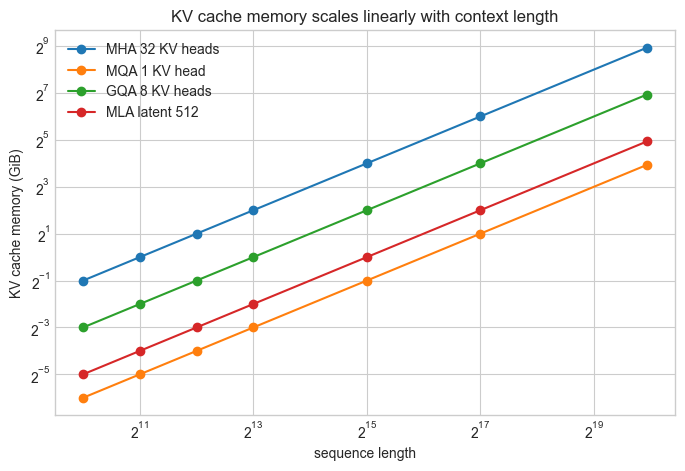

In [33]:
def latent_cache_bytes(
    seq_len,
    latent_dim,
    batch_size=CONFIG["batch_size"],
    num_layers=CONFIG["num_layers"],
    dtype=CONFIG["dtype"],
):
    return batch_size * seq_len * num_layers * latent_dim * DTYPE_BYTES[dtype]


seq_lens = np.array([1024, 2048, 4096, 8192, 32768, 131072, 1_000_000])
curves = {
    "MHA 32 KV heads": [kv_cache_bytes(n, 32) for n in seq_lens],
    "MQA 1 KV head": [kv_cache_bytes(n, 1) for n in seq_lens],
    "GQA 8 KV heads": [kv_cache_bytes(n, 8) for n in seq_lens],
    "MLA latent 512": [latent_cache_bytes(n, 512) for n in seq_lens],
}

plt.figure(figsize=(8, 5))
for label, values in curves.items():
    plt.plot(seq_lens, [bytes_to_gib(v) for v in values], marker="o", label=label)
plt.xscale("log", base=2)
plt.yscale("log", base=2)
plt.xlabel("sequence length")
plt.ylabel("KV cache memory (GiB)")
plt.title("KV cache memory scales linearly with context length")
plt.legend()
plt.show()

## 5. Clean Variant Comparison

Compare variants by **cached scalars per token per layer**.

For head-based KV cache:

```text
cached scalars = 2 * num_kv_heads * head_dim
```

For simplified MLA:

```text
cached scalars = latent_dim
```

With `head_dim = 128`:

- MHA-32 stores `2 * 32 * 128 = 8192` scalars/token/layer
- MQA stores `2 * 1 * 128 = 256` scalars/token/layer
- GQA-8 stores `2 * 8 * 128 = 2048` scalars/token/layer
- simplified MLA-512 stores `512` scalars/token/layer

In [ ]:
seq_len = 32768
head_dim = CONFIG["head_dim"]
mha = kv_cache_bytes(seq_len, 32)
mqa = kv_cache_bytes(seq_len, 1)
gqa = kv_cache_bytes(seq_len, 8)
mla = latent_cache_bytes(seq_len, 512)

variant_rows = [
    ["MHA", 2 * 32 * head_dim, "32 KV heads", fmt_bytes(mha), "1.0x"],
    ["MQA", 2 * 1 * head_dim, "1 KV head", fmt_bytes(mqa), f"{mha / mqa:.1f}x smaller"],
    ["GQA-8", 2 * 8 * head_dim, "8 KV heads", fmt_bytes(gqa), f"{mha / gqa:.1f}x smaller"],
    ["MLA-512", 512, "latent width", fmt_bytes(mla), f"{mha / mla:.1f}x smaller"],
]
print_table(
    ["variant", "scalars/token/layer", "stored cache", "memory", "vs MHA"],
    variant_rows,
)

<svg width="860" height="240" viewBox="0 0 860 240" xmlns="http://www.w3.org/2000/svg">
  <style>
    .title { font: 700 16px sans-serif; fill: #111; }
    .label { font: 12px sans-serif; fill: #111; }
    .small { font: 11px sans-serif; fill: #333; }
    .q { fill: #f4a261; stroke: #8a4f0f; stroke-width: 1.5; }
    .kv { fill: #4c78a8; stroke: #163b5c; stroke-width: 1.5; }
    .latent { fill: #59a14f; stroke: #2f6b2f; stroke-width: 1.5; }
    .line { stroke: #555; stroke-width: 1.2; }
  </style>
  <text x="20" y="24" class="title">MHA</text>
  <text x="235" y="24" class="title">MQA</text>
  <text x="450" y="24" class="title">GQA</text>
  <text x="665" y="24" class="title">MLA</text>
  <g transform="translate(20 50)">
    <rect x="0" y="0" width="38" height="26" rx="4" class="q"/><text x="10" y="18" class="label">Q0</text>
    <rect x="60" y="0" width="46" height="26" rx="4" class="kv"/><text x="70" y="18" class="label">KV0</text>
    <line x1="38" y1="13" x2="60" y2="13" class="line"/>
    <rect x="0" y="36" width="38" height="26" rx="4" class="q"/><text x="10" y="54" class="label">Q1</text>
    <rect x="60" y="36" width="46" height="26" rx="4" class="kv"/><text x="70" y="54" class="label">KV1</text>
    <line x1="38" y1="49" x2="60" y2="49" class="line"/>
    <rect x="0" y="72" width="38" height="26" rx="4" class="q"/><text x="10" y="90" class="label">Q2</text>
    <rect x="60" y="72" width="46" height="26" rx="4" class="kv"/><text x="70" y="90" class="label">KV2</text>
    <line x1="38" y1="85" x2="60" y2="85" class="line"/>
    <text x="0" y="124" class="small">one KV per Q head</text>
  </g>
  <g transform="translate(235 50)">
    <rect x="0" y="0" width="38" height="26" rx="4" class="q"/><text x="10" y="18" class="label">Q0</text>
    <rect x="0" y="36" width="38" height="26" rx="4" class="q"/><text x="10" y="54" class="label">Q1</text>
    <rect x="0" y="72" width="38" height="26" rx="4" class="q"/><text x="10" y="90" class="label">Q2</text>
    <rect x="75" y="32" width="50" height="38" rx="4" class="kv"/><text x="91" y="56" class="label">KV</text>
    <line x1="38" y1="13" x2="75" y2="51" class="line"/>
    <line x1="38" y1="49" x2="75" y2="51" class="line"/>
    <line x1="38" y1="85" x2="75" y2="51" class="line"/>
    <text x="0" y="124" class="small">one shared KV head</text>
  </g>
  <g transform="translate(450 50)">
    <rect x="0" y="0" width="38" height="26" rx="4" class="q"/><text x="10" y="18" class="label">Q0</text>
    <rect x="0" y="36" width="38" height="26" rx="4" class="q"/><text x="10" y="54" class="label">Q1</text>
    <rect x="72" y="18" width="50" height="34" rx="4" class="kv"/><text x="84" y="40" class="label">KV0</text>
    <line x1="38" y1="13" x2="72" y2="35" class="line"/>
    <line x1="38" y1="49" x2="72" y2="35" class="line"/>
    <rect x="0" y="88" width="38" height="26" rx="4" class="q"/><text x="10" y="106" class="label">Q2</text>
    <rect x="72" y="84" width="50" height="34" rx="4" class="kv"/><text x="84" y="106" class="label">KV1</text>
    <line x1="38" y1="101" x2="72" y2="101" class="line"/>
    <text x="0" y="144" class="small">groups share KV heads</text>
  </g>
  <g transform="translate(665 50)">
    <rect x="0" y="0" width="38" height="26" rx="4" class="q"/><text x="10" y="18" class="label">Q0</text>
    <rect x="0" y="42" width="38" height="26" rx="4" class="q"/><text x="10" y="60" class="label">Q1</text>
    <rect x="0" y="84" width="38" height="26" rx="4" class="q"/><text x="10" y="102" class="label">Q2</text>
    <rect x="70" y="22" width="78" height="62" rx="6" class="latent"/>
    <text x="88" y="50" class="label">latent</text>
    <text x="88" y="68" class="label">cache</text>
    <line x1="38" y1="13" x2="70" y2="53" class="line"/>
    <line x1="38" y1="55" x2="70" y2="53" class="line"/>
    <line x1="38" y1="97" x2="70" y2="53" class="line"/>
    <text x="0" y="134" class="small">compressed cache state</text>
  </g>
</svg>

## 6. Decode Read vs Write

At each decode step, dense attention reads old K/V and writes one new K/V entry.
Read grows with context length. Write is one token.

In [ ]:
prompt_len = 8192
generated = 512
steps = np.arange(generated)
cache_lens = prompt_len + steps

read_mib = np.array([bytes_to_mib(kv_cache_bytes(n, 32)) for n in cache_lens])
write_mib = bytes_to_mib(kv_cache_bytes(1, 32))
write_line = np.full_like(read_mib, write_mib, dtype=float)

summary = [
    ["first decode read", fmt_bytes(kv_cache_bytes(prompt_len, 32))],
    ["last decode read", fmt_bytes(kv_cache_bytes(prompt_len + generated - 1, 32))],
    ["new-token KV write", fmt_bytes(kv_cache_bytes(1, 32))],
    ["first read/write ratio", f"{read_mib[0] / write_mib:.0f}x"],
]
print_table(["quantity", "value"], summary)

plt.figure(figsize=(8, 4.8))
plt.plot(steps, read_mib, label="dense K/V read per decode token")
plt.plot(steps, write_line, label="new K/V write per decode token")
plt.yscale("log")
plt.xlabel("generated token index")
plt.ylabel("MiB per decode step")
plt.title("Decode is read-heavy: old cache read vs new cache write")
plt.legend()
plt.show()

## 7. Attention Read/Write Components

Logical components for one dense decode token:

- read cached K/V
- compute score matrix `[layers, query_heads, cache_len]`
- write the attention output for one token
- append new K/V

Many kernels avoid materializing the full score matrix. The score bytes below are
logical size, not necessarily actual memory traffic.

In [ ]:
def score_bytes_if_materialized(cache_len, dtype=CONFIG["dtype"]):
    return (
        CONFIG["batch_size"]
        * CONFIG["num_layers"]
        * CONFIG["num_query_heads"]
        * cache_len
        * DTYPE_BYTES[dtype]
    )


def attention_output_write_bytes(dtype=CONFIG["dtype"]):
    hidden_size = CONFIG["num_query_heads"] * CONFIG["head_dim"]
    return CONFIG["batch_size"] * CONFIG["num_layers"] * hidden_size * DTYPE_BYTES[dtype]


component_rows = []
for cache_len in [4096, 32768, 131072]:
    kv_read = kv_cache_bytes(cache_len, 32)
    score_bytes = score_bytes_if_materialized(cache_len)
    out_write = attention_output_write_bytes()
    kv_write = kv_cache_bytes(1, 32)
    component_rows.append(
        [
            cache_len,
            fmt_bytes(kv_read),
            fmt_bytes(score_bytes),
            fmt_bytes(out_write),
            fmt_bytes(kv_write),
        ]
    )

print_table(
    ["cache_len", "KV read", "scores", "attn out write", "KV write"],
    component_rows,
)

In [ ]:
cache_lens = np.array([1024, 4096, 8192, 32768, 131072, 1_000_000])
components = {
    "KV read": [kv_cache_bytes(n, 32) for n in cache_lens],
    "scores if materialized": [score_bytes_if_materialized(n) for n in cache_lens],
    "attention output write": [attention_output_write_bytes() for _ in cache_lens],
    "new KV write": [kv_cache_bytes(1, 32) for _ in cache_lens],
}

plt.figure(figsize=(8, 4.8))
for label, values in components.items():
    plt.plot(cache_lens, [bytes_to_mib(v) for v in values], marker="o", label=label)
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("cache length")
plt.ylabel("MiB")
plt.title("Dense decode component sizes for one new token")
plt.legend()
plt.show()

## 8. Cumulative Decode Reads

Generating `T` tokens from prompt length `L` reads positions proportional to:

```text
L + (L + 1) + ... + (L + T - 1)
= T * L + T * (T - 1) / 2
```

In [ ]:
def total_dense_decode_positions(prompt_len, generated_tokens):
    return generated_tokens * prompt_len + generated_tokens * (generated_tokens - 1) // 2


def cumulative_decode_read_bytes(prompt_len, generated_tokens, num_kv_heads):
    positions = total_dense_decode_positions(prompt_len, generated_tokens)
    return kv_cache_bytes(positions, num_kv_heads)


def cumulative_decode_write_bytes(generated_tokens, num_kv_heads):
    return kv_cache_bytes(generated_tokens, num_kv_heads)


rows = []
for gen_tokens in [1, 16, 128, 1024, 4096]:
    read_bytes = cumulative_decode_read_bytes(8192, gen_tokens, 32)
    write_bytes = cumulative_decode_write_bytes(gen_tokens, 32)
    rows.append(
        [
            gen_tokens,
            fmt_bytes(read_bytes),
            fmt_bytes(write_bytes),
            f"{read_bytes / write_bytes:.0f}x",
        ]
    )

print_table(["generated", "cum KV read", "cum KV write", "read/write"], rows)

In [ ]:
generated_tokens = np.array([1, 4, 16, 64, 256, 1024, 4096])
read_gib = [bytes_to_gib(cumulative_decode_read_bytes(8192, t, 32)) for t in generated_tokens]
write_gib = [bytes_to_gib(cumulative_decode_write_bytes(t, 32)) for t in generated_tokens]

plt.figure(figsize=(8, 4.8))
plt.plot(generated_tokens, read_gib, marker="o", label="cumulative dense KV read")
plt.plot(generated_tokens, write_gib, marker="o", label="cumulative KV write")
plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("generated tokens")
plt.ylabel("GiB")
plt.title("Cumulative decode: reads dominate writes")
plt.legend()
plt.show()

## 9. GQA Head Mapping

For 32 query heads and 8 KV heads, each KV head serves 4 query heads.

In [ ]:
def kv_head_for_query_head(query_head, num_query_heads, num_kv_heads):
    if num_query_heads % num_kv_heads != 0:
        raise ValueError("num_query_heads must divide evenly by num_kv_heads")
    group_size = num_query_heads // num_kv_heads
    return query_head // group_size


q_heads = np.arange(32)
kv_heads = np.array([kv_head_for_query_head(q, 32, 8) for q in q_heads])

print_table(
    ["query heads", "mapped KV head"],
    [[f"{4 * i}-{4 * i + 3}", i] for i in range(8)],
)

plt.figure(figsize=(8, 3.5))
plt.step(q_heads, kv_heads, where="post")
plt.scatter(q_heads, kv_heads, s=20)
plt.xlabel("query head")
plt.ylabel("KV head")
plt.title("GQA mapping: 32 query heads -> 8 KV heads")
plt.yticks(range(8))
plt.show()

## 10. Sparse/CSA Read Math

Simplified CSA read count:

```text
compressed_entries = ceil(seq_len / block_size)
reads = min(top_k, compressed_entries) + min(local_window, seq_len)
```

This measures selected entries, not model quality.

In [ ]:
def ceil_div(a, b):
    return (a + b - 1) // b


def compressed_entries(seq_len, block_size):
    return ceil_div(seq_len, block_size)


def dense_reads(seq_len):
    return seq_len


def csa_reads(seq_len, block_size, top_k, local_window):
    selected_compressed = min(top_k, compressed_entries(seq_len, block_size))
    selected_local = min(local_window, seq_len)
    return selected_compressed + selected_local


rows = []
for seq_len in [4096, 32768, 131072, 1_000_000]:
    dense = dense_reads(seq_len)
    sparse = csa_reads(seq_len, block_size=64, top_k=128, local_window=256)
    rows.append([seq_len, dense, sparse, f"{dense / sparse:.1f}x"])

print_table(["seq_len", "dense reads", "CSA reads", "reduction"], rows)

In [ ]:
seq_lens = np.array([1024, 4096, 8192, 32768, 131072, 1_000_000])
dense_curve = [dense_reads(n) for n in seq_lens]
csa_curve = [csa_reads(n, block_size=64, top_k=128, local_window=256) for n in seq_lens]
reduction = np.array(dense_curve) / np.array(csa_curve)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(seq_lens, dense_curve, marker="o", label="dense")
axes[0].plot(seq_lens, csa_curve, marker="o", label="simplified CSA")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("sequence length")
axes[0].set_ylabel("entries read per decode query")
axes[0].set_title("Dense vs sparse reads")
axes[0].legend()

axes[1].plot(seq_lens, reduction, marker="o", color="tab:green")
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("sequence length")
axes[1].set_ylabel("read reduction factor")
axes[1].set_title("Sparse read reduction grows with context")
plt.show()

## 12. Takeaways

- KV cache stores K and V, usually not Q.
- MHA/MQA/GQA change `num_kv_heads`.
- MLA changes the stored representation; `MLA-512` here is latent width, not heads.
- Dense decode is read-heavy because every new token scans old K/V.
- Sparse/CSA reduces read count, but quality depends on selecting useful context.
- Next implementation target: dense MHA with explicit prefill/decode cache.